# DD2424 - Assignment 1
This is the main notebook containing the training for the first assignment of DD2424.
## 1. Prelimenary testing
This section contains the prelimenary testing of all the code componenets, f.e. the forward and backward pass, training, ...

### Loading the dataset

In [2]:
from utils import load_batch
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X, Y, y = load_batch("data_batch_1")

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


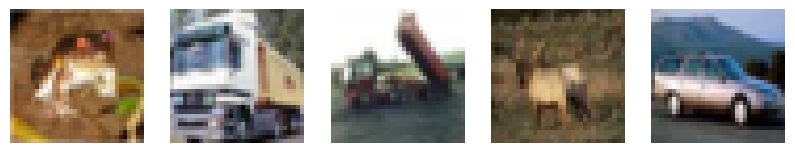

In [4]:
ni = 5
fig, axs = plt.subplots(1, 5, figsize=(10, 5))
for i in range(ni):
    X_im = X[:, i].reshape((32, 32, 3), order='F')
    X_im = np.transpose(X_im, (1, 0, 2))
    axs[i].imshow(X_im)
    axs[i].axis('off')
plt.pause(0.1)

### Scaling the dataset

In [5]:
from scaler import Scaler

scaler = Scaler()
X_train = scaler.fit_transform(X)

In [6]:
# check if scaling was successful
print("The mean for the first 10 samples after scaling:")
print(np.mean(X_train, axis=1)[:10])
print("The standard deviation for the first 10 samples after scaling:")
print(np.std(X_train, axis=1)[:10])

The mean for the first 10 samples after scaling:
[ 1.14188659e-15 -6.76236844e-15 -3.25716121e-15 -3.70345976e-15
 -4.23336921e-15 -6.02889683e-15 -5.62281888e-15 -5.79015169e-15
 -7.25770555e-15 -7.57909291e-15]
The standard deviation for the first 10 samples after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Testing forward pass

In [7]:
from model import Model
model = Model(32*32*3, 10)
Y_pred = model.forward(X_train[:, :100])
Y_pred.shape

(10, 100)

In [8]:
Y_pred[:,0]

array([ 0.05121096,  0.62430223,  0.37207589,  0.0456761 , -0.43508798,
       -0.38045104, -0.52871895,  0.16379476, -0.18598619,  0.07368599])

In [9]:
from nodes import CrossEntropyLoss
loss_node = CrossEntropyLoss()

loss = loss_node.forward(Y_pred, Y[:, :100])
print(f"loss computed {loss}")

loss computed 2.4165355967198696


## Testing backward pass - gradient calculation

In [10]:
grad = loss_node.backward()
print(grad.shape)

(10, 100)


In [11]:
model.backward(grad)
my_W_grad = model.layers[0].grad_W.flatten()
my_b_grad = model.layers[0].grad_b.flatten()

In [12]:
from torch_gradient_computations import ComputeGradsWithTorch
grads_torch = ComputeGradsWithTorch(X_train[:, :100], y[:100], model.layers[0].W, model.layers[0].b)
torch_W_grad = grads_torch['W'].flatten()
torch_b_grad = grads_torch['b'].flatten()

Loss computed with PyTorch: 2.416535596720


In [13]:
from utils import calculate_mean_grad_difference

W_diff = calculate_mean_grad_difference(my_W_grad, torch_W_grad)
b_diff = calculate_mean_grad_difference(my_b_grad, torch_b_grad)
print(f"Mean absolute difference in W gradients: {W_diff}")
print(f"Mean absolute difference in b gradients: {b_diff}")

Mean absolute difference in W gradients: 2.1095277491209284e-16
Mean absolute difference in b gradients: 1.2746840824122078e-16


### Testing model training

In [14]:
from optimizer import Optimizer
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)

In [15]:
X, Y, y = load_batch("data_batch_1")
X_train = X[:, :7000]
y_train = y[:7000]
X_val = X[:, 7000:]
y_val = y[7000:]
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [16]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=50)

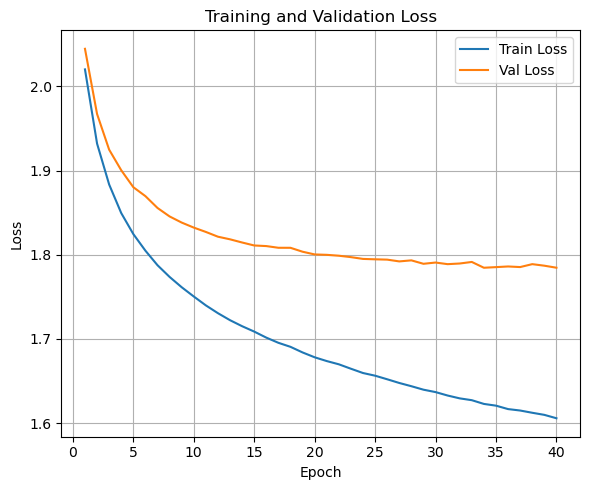

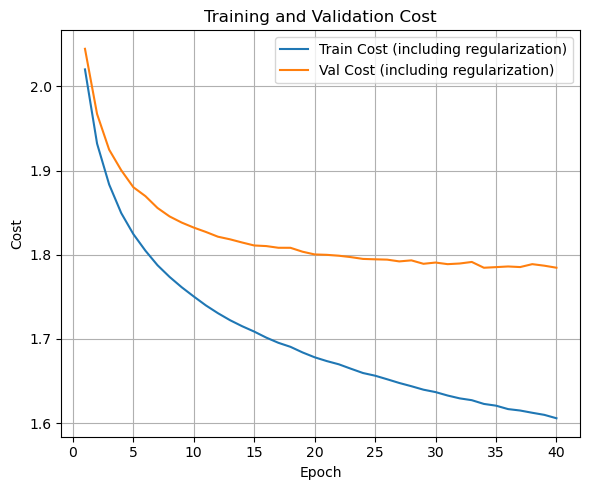

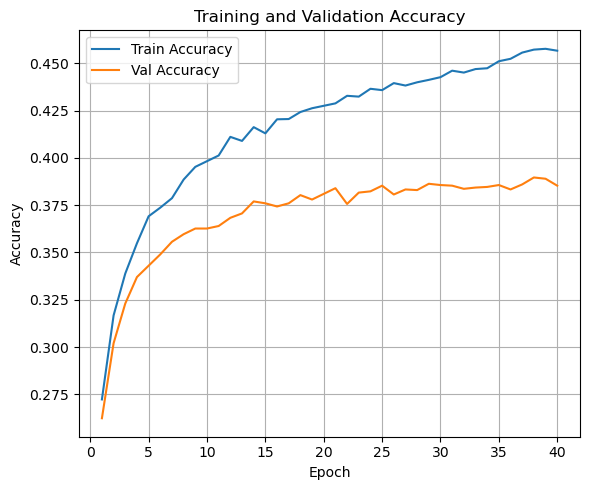

In [17]:
optimizer.plot_training_progress()

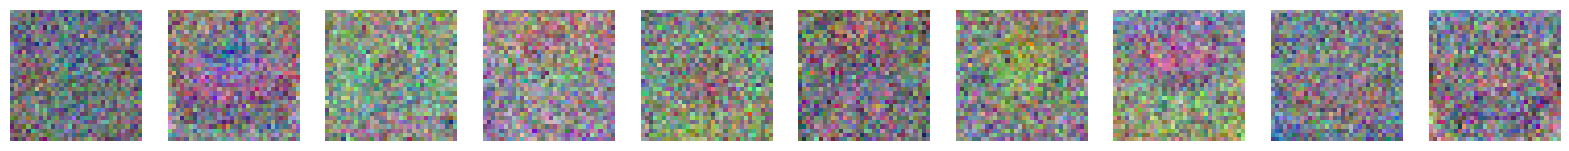

In [18]:
import numpy as np
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')

## 2. Assignment tasks
- Generate the graph of **loss**, **cost function**(loss + regularization), and **accuracy** on the training and testing data.
- Print the images representing the learnt weight matrix after training completion.
- Repeat for the following parameters:
  - lambda = 0, n_epochs = 40, n_batch = 100, lr = .1
  - lambda = 0, n_epochs = 40, n_batch = 100, lr = .001
  - lambda = 0.1, n_epochs = 40, n_batch = 100, lr = .001
  - lambda = 1, n_epochs = 40, n_batch = 100, lr = .001

In [38]:
# Load the train, validation and test set
X_train, Y_train, y_train = load_batch("data_batch_1")
X_val, Y_val, y_val = load_batch("data_batch_2")
X_test, Y_test, y_test = load_batch("test_batch")
# scale the data
scaler = Scaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


#### A) lambda = 0, n_epochs = 40, n_batch = 100, lr = .1

In [39]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.1, reg=0.0)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=5)

Epoch 5/40 - Train Loss: 5.9570, Val Loss: 6.9986, Train Acc: 0.3683, Val Acc: 0.2977
Epoch 10/40 - Train Loss: 6.0075, Val Loss: 7.4948, Train Acc: 0.3349, Val Acc: 0.2624
Epoch 15/40 - Train Loss: 3.8871, Val Loss: 5.6598, Train Acc: 0.3974, Val Acc: 0.2757
Epoch 20/40 - Train Loss: 5.4229, Val Loss: 7.2476, Train Acc: 0.3865, Val Acc: 0.2875
Epoch 25/40 - Train Loss: 4.0888, Val Loss: 6.1837, Train Acc: 0.4141, Val Acc: 0.2888
Epoch 30/40 - Train Loss: 4.0709, Val Loss: 6.3085, Train Acc: 0.4399, Val Acc: 0.3000
Epoch 35/40 - Train Loss: 4.3439, Val Loss: 6.7053, Train Acc: 0.4246, Val Acc: 0.2767
Epoch 40/40 - Train Loss: 4.9804, Val Loss: 7.5478, Train Acc: 0.4124, Val Acc: 0.2725


In [ ]:
# accuracy on the test set
optimizer.compute_accuracy(X_test, y_test)

np.float64(0.2702)

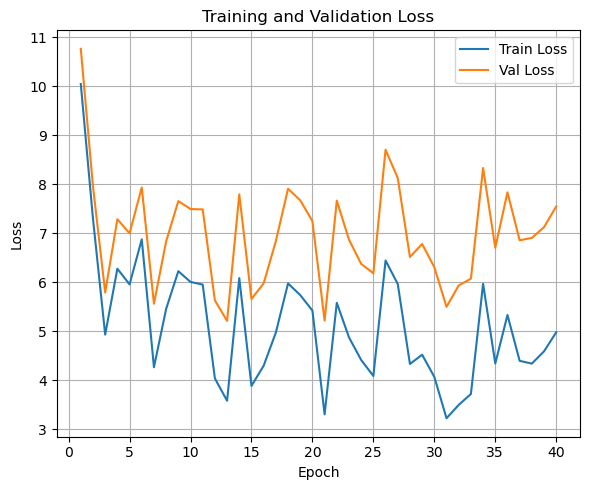

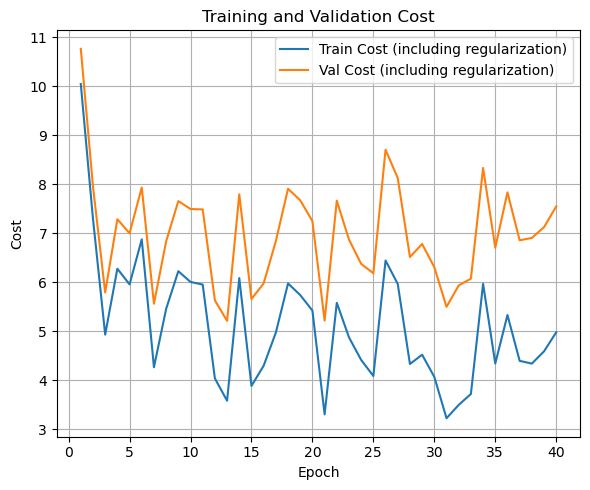

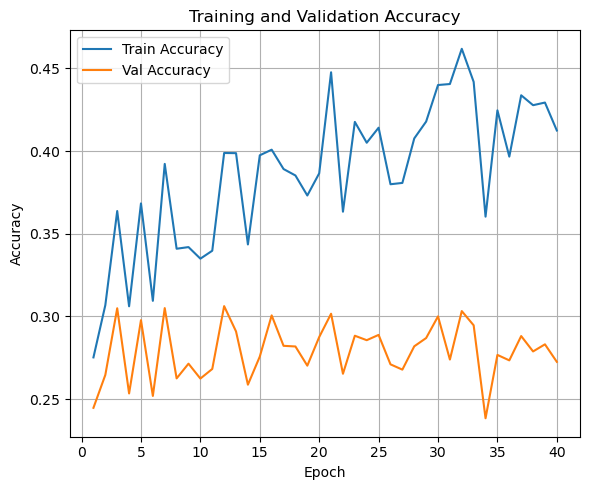

In [40]:
optimizer.plot_training_progress()

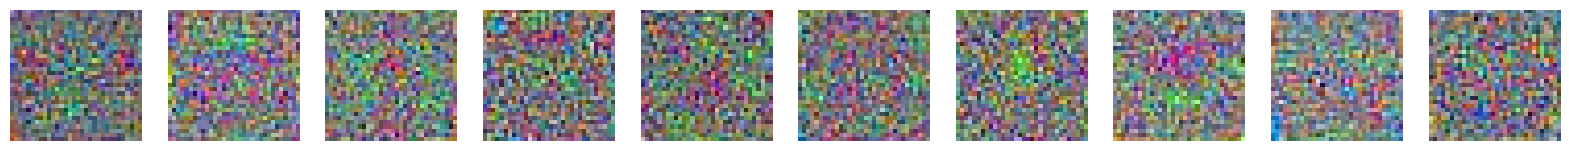

In [41]:
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')

#### B) lambda = 0, n_epochs = 40, n_batch = 100, lr = .001

In [43]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=5)

Epoch 5/40 - Train Loss: 1.8023, Val Loss: 1.8687, Train Acc: 0.3748, Val Acc: 0.3522
Epoch 10/40 - Train Loss: 1.7372, Val Loss: 1.8309, Train Acc: 0.4048, Val Acc: 0.3687
Epoch 15/40 - Train Loss: 1.7014, Val Loss: 1.8188, Train Acc: 0.4184, Val Acc: 0.3769
Epoch 20/40 - Train Loss: 1.6752, Val Loss: 1.8057, Train Acc: 0.4308, Val Acc: 0.3804
Epoch 25/40 - Train Loss: 1.6550, Val Loss: 1.8017, Train Acc: 0.4365, Val Acc: 0.3816
Epoch 30/40 - Train Loss: 1.6384, Val Loss: 1.7984, Train Acc: 0.4439, Val Acc: 0.3844
Epoch 35/40 - Train Loss: 1.6252, Val Loss: 1.7945, Train Acc: 0.4544, Val Acc: 0.3858
Epoch 40/40 - Train Loss: 1.6123, Val Loss: 1.7941, Train Acc: 0.4558, Val Acc: 0.3861


In [44]:
# accuracy on the test set
optimizer.compute_accuracy(X_test, y_test)

np.float64(0.3876)

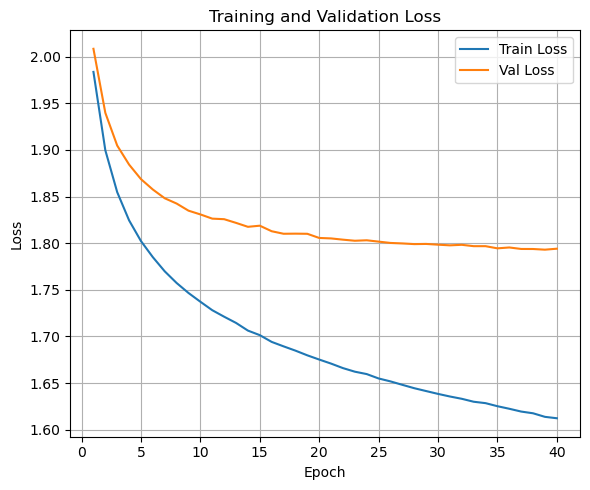

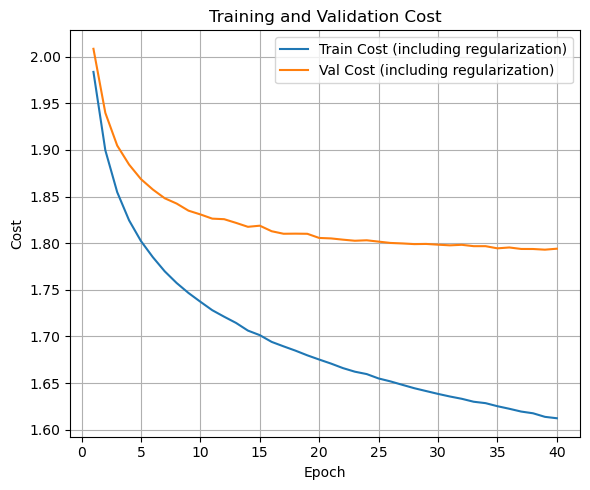

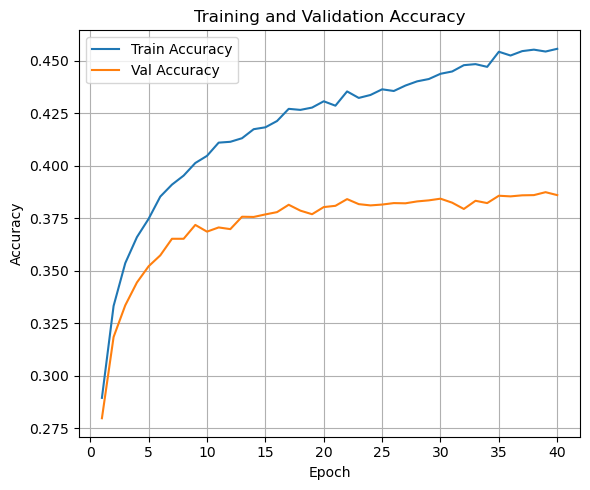

In [45]:
optimizer.plot_training_progress()

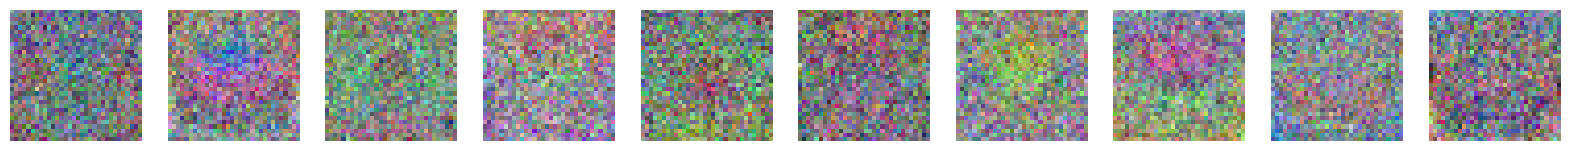

In [46]:
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')

#### C) lambda = 0.1, n_epochs = 40, n_batch = 100, lr = .001

In [47]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.1)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=5)

Epoch 5/40 - Train Loss: 1.8036, Val Loss: 1.8678, Train Acc: 0.3758, Val Acc: 0.3542
Epoch 10/40 - Train Loss: 1.7421, Val Loss: 1.8295, Train Acc: 0.4053, Val Acc: 0.3719
Epoch 15/40 - Train Loss: 1.7104, Val Loss: 1.8169, Train Acc: 0.4173, Val Acc: 0.3764
Epoch 20/40 - Train Loss: 1.6888, Val Loss: 1.8031, Train Acc: 0.4296, Val Acc: 0.3817
Epoch 25/40 - Train Loss: 1.6733, Val Loss: 1.7984, Train Acc: 0.4342, Val Acc: 0.3840
Epoch 30/40 - Train Loss: 1.6618, Val Loss: 1.7946, Train Acc: 0.4375, Val Acc: 0.3878
Epoch 35/40 - Train Loss: 1.6538, Val Loss: 1.7903, Train Acc: 0.4461, Val Acc: 0.3884
Epoch 40/40 - Train Loss: 1.6460, Val Loss: 1.7890, Train Acc: 0.4465, Val Acc: 0.3889


In [48]:
# accuracy on the test set
optimizer.compute_accuracy(X_test, y_test)

np.float64(0.392)

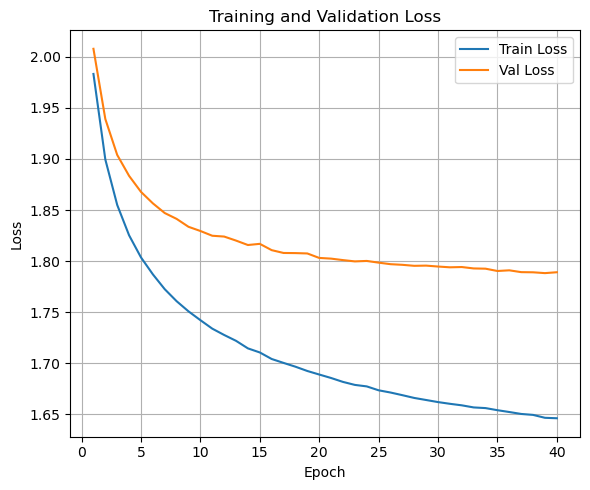

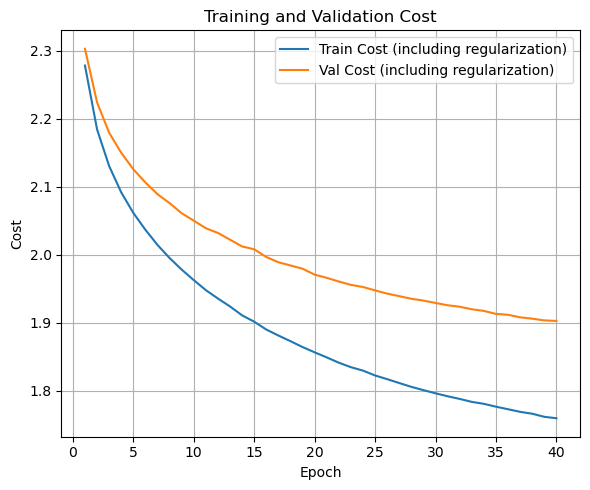

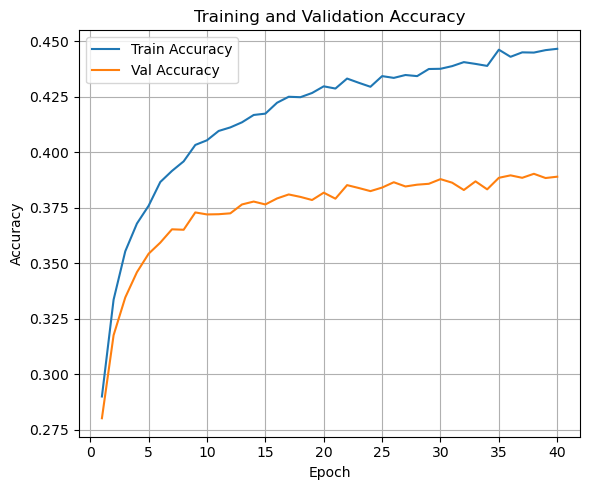

In [50]:
optimizer.plot_training_progress()

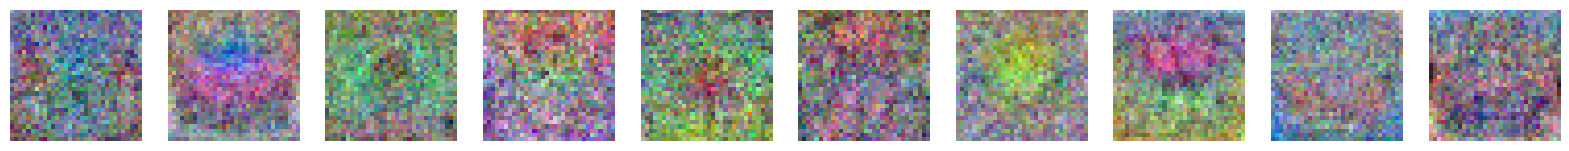

In [51]:
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')

#### D) lambda = 1.0, n_epochs = 40, n_batch = 100, lr = .001

In [52]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=1.0)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=5)

Epoch 5/40 - Train Loss: 1.8358, Val Loss: 1.8852, Train Acc: 0.3774, Val Acc: 0.3542
Epoch 10/40 - Train Loss: 1.8127, Val Loss: 1.8680, Train Acc: 0.3951, Val Acc: 0.3661
Epoch 15/40 - Train Loss: 1.8076, Val Loss: 1.8684, Train Acc: 0.3927, Val Acc: 0.3601
Epoch 20/40 - Train Loss: 1.8049, Val Loss: 1.8621, Train Acc: 0.4018, Val Acc: 0.3667
Epoch 25/40 - Train Loss: 1.8035, Val Loss: 1.8625, Train Acc: 0.3985, Val Acc: 0.3609
Epoch 30/40 - Train Loss: 1.8027, Val Loss: 1.8624, Train Acc: 0.3973, Val Acc: 0.3638
Epoch 35/40 - Train Loss: 1.8045, Val Loss: 1.8619, Train Acc: 0.4032, Val Acc: 0.3690
Epoch 40/40 - Train Loss: 1.8030, Val Loss: 1.8625, Train Acc: 0.4028, Val Acc: 0.3642


In [54]:
# accuracy on the test set
optimizer.compute_accuracy(X_test, y_test)

np.float64(0.3754)

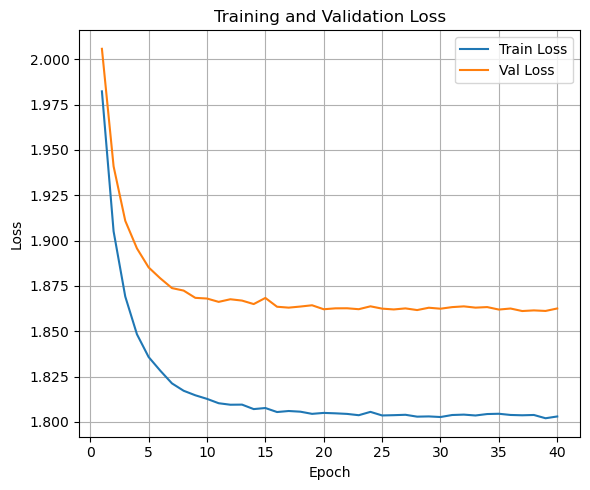

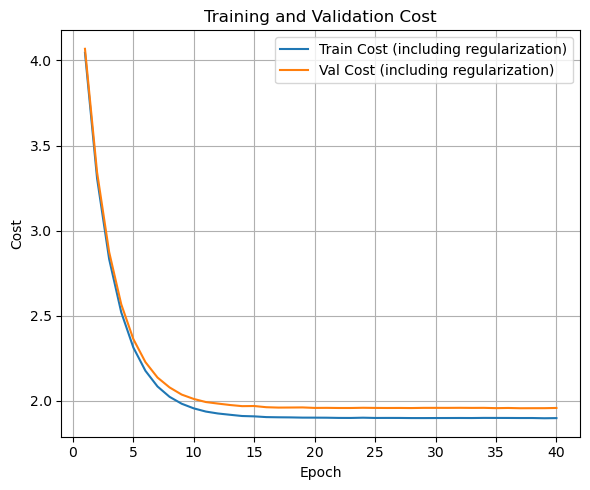

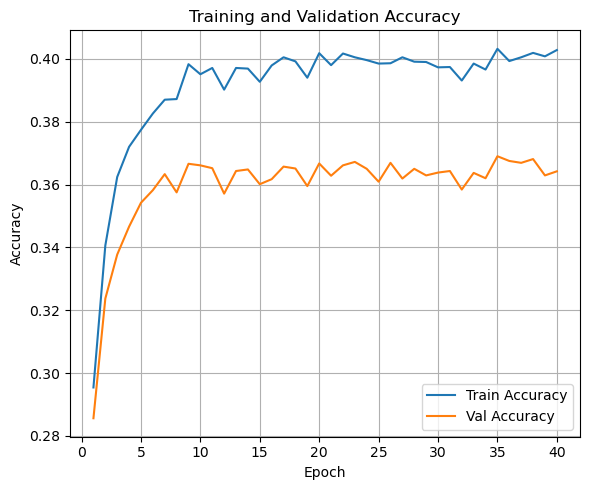

In [55]:
optimizer.plot_training_progress()

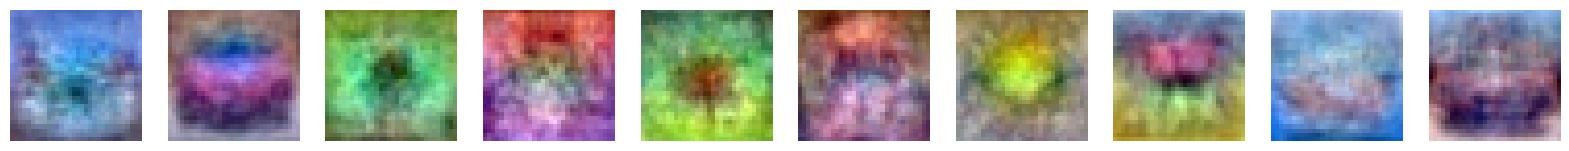

In [56]:
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')